# Homework 2 — Image Compression with SVD

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

An image is just a matrix of numbers, and the singular value decomposition $A = U \Sigma V^{T}$ orders that matrix into directions sorted by how much of it they explain. Keeping only the first $k$ singular values gives the best rank-$k$ approximation of the image, which is exactly what lossy compression needs. Below the decomposition is applied to two photographs, and the trade-off between $k$, storage and visual quality is measured.

In [1]:
# Environment setup & imports
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn.datasets
from sklearn.decomposition import TruncatedSVD

plt.rcParams.update({"figure.dpi": 85, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

## Step 1: Prepare and Display the Images

Two RGB photographs in JPEG format are used. They ship with scikit-learn, so the notebook runs identically in Colab and locally without any upload step — but they are ordinary `.jpg` files on disk, read with `matplotlib.pyplot.imread`.

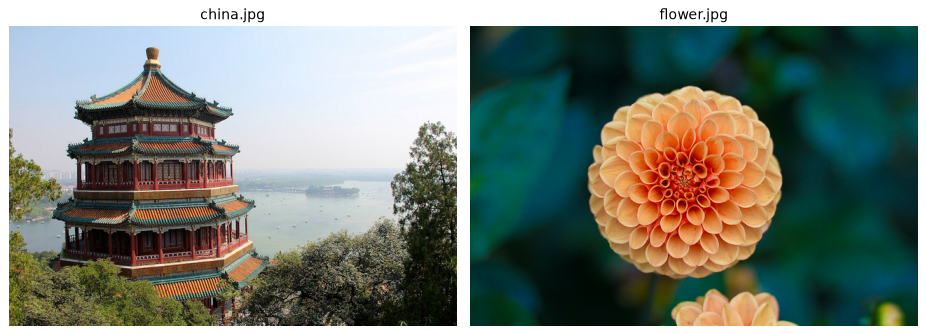

In [2]:
IMAGES_DIR = pathlib.Path(sklearn.datasets.__file__).parent / "images"

images = {name: plt.imread(str(IMAGES_DIR / f"{name}.jpg")) for name in ("china", "flower")}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, image) in zip(axes, images.items()):
    ax.imshow(image)
    ax.set_title(f"{name}.jpg")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 2: Image Size and Matrix Representation

`shape` returns `(height, width, channels)`: every image is a stack of three 2D matrices, one per color channel, with `uint8` intensities in $[0, 255]$.

In [3]:
for name, image in images.items():
    height, width, channels = image.shape
    print(
        f"{name:7s} shape={image.shape}  dtype={image.dtype}  "
        f"range=[{image.min()}, {image.max()}]  pixels={height * width * channels:,}"
    )

# the detailed walk-through of steps 3-6 is done on one image
image = images["china"]
height, width, channels = image.shape

china   shape=(427, 640, 3)  dtype=uint8  range=[0, 255]  pixels=819,840
flower  shape=(427, 640, 3)  dtype=uint8  range=[0, 255]  pixels=819,840


## Step 3: Reshape the 3D Image into a 2D Matrix

SVD is defined for 2D matrices only. The three channels are flattened and stacked horizontally, so row $i$ of the result holds image row $i$ with its R, G and B values interleaved:

$$(\text{height},\ \text{width},\ 3) \longrightarrow (\text{height},\ \text{width} \cdot 3)$$

The matrix is cast to `float64` — SVD on `uint8` would overflow and reconstructions are not integers anyway.

In [4]:
flat_image = image.reshape(-1, width * channels).astype(np.float64)

print(f"3D image:  {image.shape}")
print(f"2D matrix: {flat_image.shape}")
print(f"Maximum rank: {min(flat_image.shape)}")

3D image:  (427, 640, 3)
2D matrix: (427, 1920)
Maximum rank: 427


## Step 4: SVD Decomposition

`np.linalg.svd` factorizes the matrix as $A = U \Sigma V^{T}$, where $\Sigma$ holds the singular values in descending order. With `full_matrices=False` only the economy-size factors are returned, which is all that is needed here: $U$ is $427 \times 427$, $V^{T}$ is $427 \times 1920$.

In [5]:
U, S, Vt = np.linalg.svd(flat_image, full_matrices=False)

print(f"U:  {U.shape}")
print(f"S:  {S.shape}")
print(f"Vt: {Vt.shape}")
print(f"\nFirst 10 singular values:\n{S[:10].round(1)}")
print(f"\nFull decomposition restores the matrix exactly: {np.allclose(U @ np.diag(S) @ Vt, flat_image)}")

U:  (427, 427)
S:  (427,)
Vt: (427, 1920)

First 10 singular values:
[144583.9  27000.7  18527.5  10557.4   9023.8   7485.6   7131.3   6293.2
   5915.8   5461.5]

Full decomposition restores the matrix exactly: True


## Step 5: The Spectrum of $\Sigma$

Plotting $\Sigma$ shows how fast the singular values decay — the steeper the drop, the more redundant the image and the better it compresses. A logarithmic scale is used because $\sigma_1$ is an order of magnitude larger than the rest: it carries the average brightness of the whole image.

The second panel shows the cumulative share of energy $\sum_{i \le k} \sigma_i^2 \big/ \sum_i \sigma_i^2$, which is the fraction of the squared Frobenius norm retained by a rank-$k$ approximation.

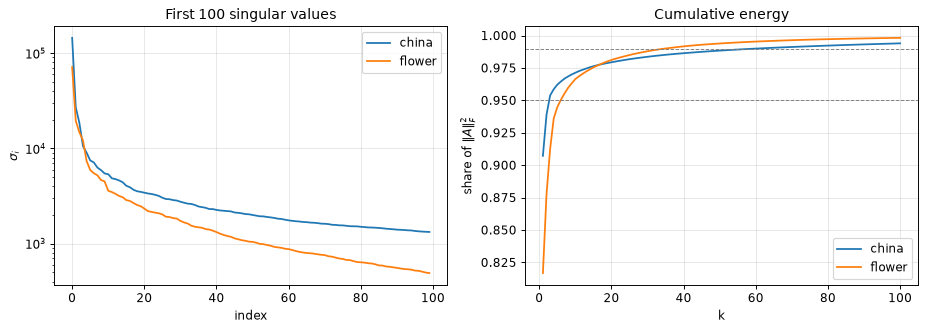

china   sigma_1=   144,584  95% energy at k=  3  99% energy at k= 61
flower  sigma_1=    71,342  95% energy at k=  6  99% energy at k= 35


In [6]:
k_plot = 100
spectra = {}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, img in images.items():
    flat = img.reshape(-1, img.shape[1] * img.shape[2]).astype(np.float64)
    singular_values = np.linalg.svd(flat, compute_uv=False)
    energy = np.cumsum(singular_values**2) / np.sum(singular_values**2)
    spectra[name] = (singular_values, energy)

    axes[0].plot(np.arange(k_plot), singular_values[:k_plot], label=name)
    axes[1].plot(np.arange(1, k_plot + 1), energy[:k_plot], label=name)

axes[0].set(title=f"First {k_plot} singular values", xlabel="index", ylabel="$\\sigma_i$", yscale="log")
axes[1].set(title="Cumulative energy", xlabel="k", ylabel="share of $\\|A\\|_F^2$")
for level in (0.95, 0.99):
    axes[1].axhline(level, color="gray", linestyle="--", linewidth=0.8)
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

for name, (singular_values, energy) in spectra.items():
    k95, k99 = np.searchsorted(energy, [0.95, 0.99]) + 1
    print(f"{name:7s} sigma_1={singular_values[0]:10,.0f}  95% energy at k={k95:3d}  99% energy at k={k99:3d}")

Both curves fall off sharply within the first few dozen components, so the images are indeed compressible. The energy measure is optimistic, though: `china` reaches 95% at $k=3$, and a rank-3 approximation is certainly not a usable picture. Energy is dominated by the brightest, lowest-frequency structure, while perceived quality lives in the long tail — which is why the reconstructions below are judged visually as well.

## Step 6: Truncated SVD and the Reconstruction Error

`TruncatedSVD` computes the same factorization but keeps only the first $k$ components; `inverse_transform` maps the compressed representation back into the original pixel space. The reconstruction error is the mean squared error between the original and reconstructed matrices, which for an exact truncation equals the discarded energy:

$$\text{MSE} = \frac{1}{mn} \sum_{i > k} \sigma_i^{2}$$

Both quantities are printed below; the small discrepancy comes from the randomized solver `TruncatedSVD` uses by default. Reconstructed values are also real numbers that leak outside $[0, 255]$, so they are clipped and cast back to `uint8` before display.

Compressed representation: (427, 100) (from (427, 1920))
Reconstruction MSE:        169.39
Discarded energy of Sigma: 168.73
Raw reconstruction range:  [-36.5, 302.0] -> clipped to [0, 255]


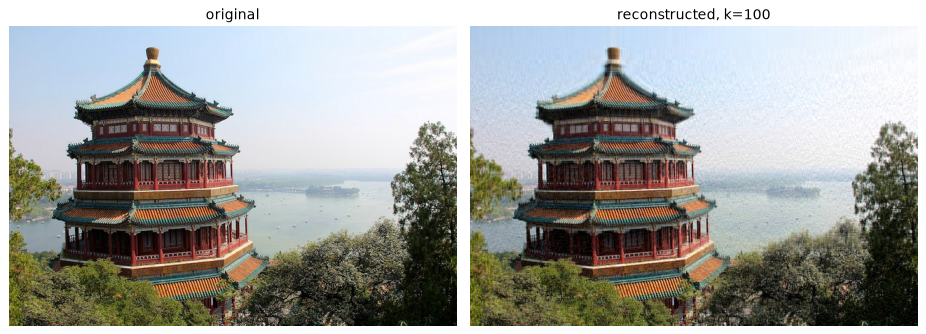

In [7]:
k = 100

svd = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
truncated_image = svd.fit_transform(flat_image)
reconstructed_image = svd.inverse_transform(truncated_image)

reconstruction_error = np.mean(np.square(reconstructed_image - flat_image))

print(f"Compressed representation: {truncated_image.shape} (from {flat_image.shape})")
print(f"Reconstruction MSE:        {reconstruction_error:.2f}")
print(f"Discarded energy of Sigma: {np.sum(S[k:] ** 2) / flat_image.size:.2f}")
print(f"Raw reconstruction range:  [{reconstructed_image.min():.1f}, {reconstructed_image.max():.1f}] -> clipped to [0, 255]")

reconstructed_image = reconstructed_image.reshape(height, width, channels)
reconstructed_image = np.clip(reconstructed_image, 0, 255).astype("uint8")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(image)
axes[0].set_title("original")
axes[1].imshow(reconstructed_image)
axes[1].set_title(f"reconstructed, k={k}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 7: Experiments with Different Values of $k$

The same pipeline is repeated for a range of $k$ on both images. Besides MSE, two more readable quantities are reported:

- **PSNR** $= 10 \log_{10}\left(255^2 / \text{MSE}\right)$ — the standard image-quality measure in dB, where 30 dB and above is usually considered visually close to the original;
- **compression ratio** — the $m \times n$ stored values of the original against the $k(m + n)$ values a rank-$k$ factorization needs.

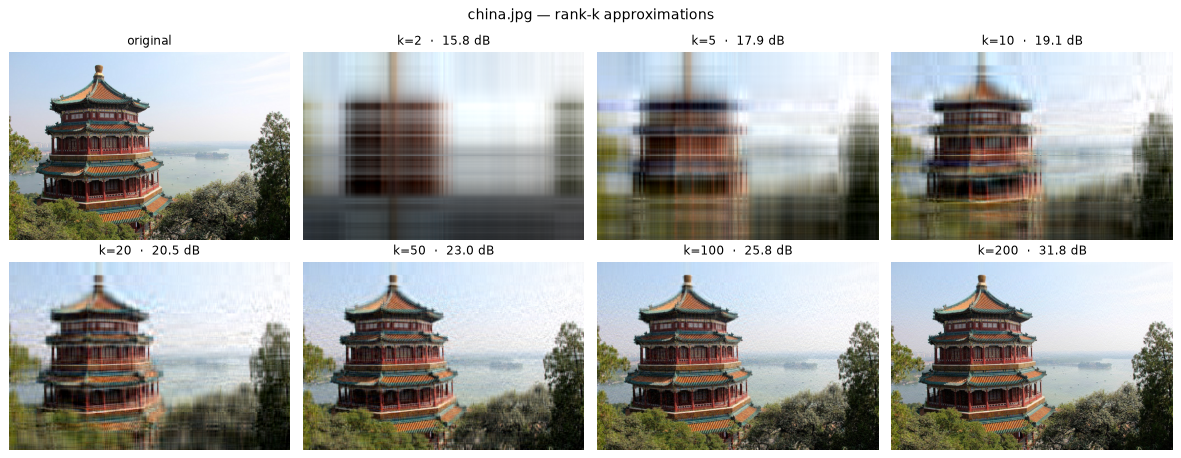

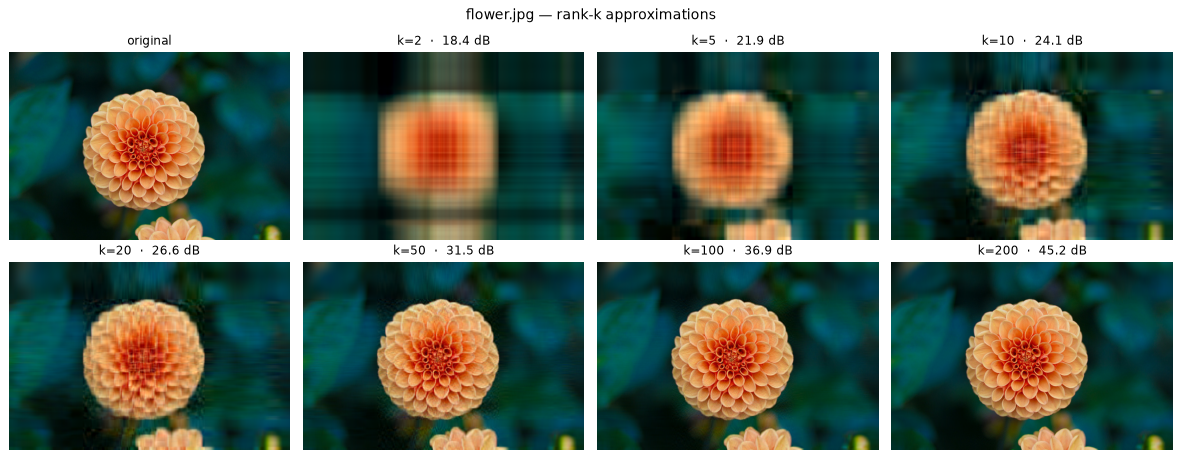

,image,k,MSE,PSNR_dB,energy_kept,compression_ratio
0,china,2,1717.507,15.782,0.939,174.657
1,china,5,1063.528,17.863,0.962,69.863
2,china,10,805.775,19.069,0.971,34.931
3,china,20,579.024,20.504,0.979,17.466
4,china,50,326.812,22.988,0.988,6.986
5,china,100,169.388,25.842,0.994,3.493
6,china,200,43.008,31.795,0.998,1.747
7,flower,2,931.908,18.437,0.877,174.657
8,flower,5,419.168,21.907,0.945,69.863
9,flower,10,254.754,24.070,0.966,34.931


In [8]:
K_VALUES = (2, 5, 10, 20, 50, 100, 200)


# rank-k approximation of a 2D matrix via truncated SVD
def compress(flat, n_components):
    model = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
    return model.inverse_transform(model.fit_transform(flat))


results = []
for name, img in images.items():
    flat = img.reshape(-1, img.shape[1] * img.shape[2]).astype(np.float64)
    m, n = flat.shape

    fig, axes = plt.subplots(2, 4, figsize=(14, 5.6))
    axes = axes.ravel()
    axes[0].imshow(img)
    axes[0].set_title("original", fontsize=10)
    for ax in axes:
        ax.axis("off")

    for ax, n_components in zip(axes[1:], K_VALUES):
        approximation = compress(flat, n_components)
        mse = np.mean(np.square(approximation - flat))
        psnr = 10 * np.log10(255.0**2 / mse)

        ax.imshow(np.clip(approximation, 0, 255).astype("uint8").reshape(img.shape))
        ax.set_title(f"k={n_components}  ·  {psnr:.1f} dB", fontsize=10)

        results.append(
            {
                "image": name,
                "k": n_components,
                "MSE": mse,
                "PSNR_dB": psnr,
                "energy_kept": spectra[name][1][n_components - 1],
                "compression_ratio": m * n / (n_components * (m + n)),
            }
        )

    fig.suptitle(f"{name}.jpg — rank-k approximations")
    plt.tight_layout()
    plt.show()

results = pd.DataFrame(results)
results.round(3)

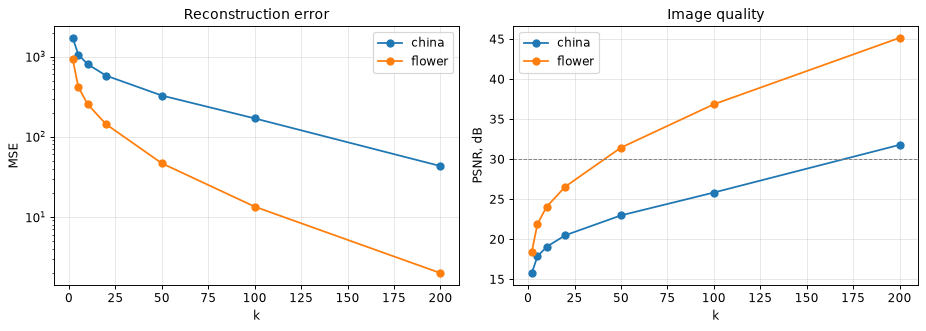

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, group in results.groupby("image"):
    axes[0].plot(group["k"], group["MSE"], marker="o", label=name)
    axes[1].plot(group["k"], group["PSNR_dB"], marker="o", label=name)

axes[0].set(title="Reconstruction error", xlabel="k", ylabel="MSE", yscale="log")
axes[1].set(title="Image quality", xlabel="k", ylabel="PSNR, dB")
axes[1].axhline(30, color="gray", linestyle="--", linewidth=0.8)
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

### Stacked Channels vs. Per-Channel SVD

Step 4 of the assignment allows either strategy, and the choice can be settled by measurement. A fair comparison fixes the storage budget rather than $k$: the stacked matrix is $427 \times 1920$, while a single channel is $427 \times 640$, so three separate decompositions cost roughly three times more per component.

In [10]:
k_stacked = 50
budget = k_stacked * sum(flat_image.shape)
k_per_channel = budget // (3 * (height + width))

mse_stacked = np.mean(np.square(compress(flat_image, k_stacked) - flat_image))
mse_per_channel = np.mean(
    [np.square(compress(image[:, :, c].astype(np.float64), k_per_channel) - image[:, :, c]) for c in range(channels)]
)

print(f"Storage budget: {budget:,} values")
print(f"Stacked channels,  k={k_stacked}: MSE = {mse_stacked:.2f}")
print(f"Per-channel SVD,   k={k_per_channel}: MSE = {mse_per_channel:.2f}")

Storage budget: 117,350 values
Stacked channels,  k=50: MSE = 326.81
Per-channel SVD,   k=36: MSE = 383.40


## Conclusion

SVD compresses these images well because their singular values decay quickly: for `china` the first 61 of 427 components already carry 99% of the energy, for `flower` only 35. Everything beyond that tail is largely redundant, and discarding it is precisely what the rank-$k$ approximation does.

**Where quality breaks down.** At $k = 2$–$5$ the reconstructions are unusable: both images collapse into smeared color blocks with strong horizontal banding — an artifact of the row-wise layout, since every row of the rank-$k$ matrix is a combination of just $k$ basis rows. At $k = 10$–$20$ the scene becomes recognizable but visibly blurred, with streaks across smooth regions. From $k = 50$ the images are close to the original, and at $k = 100$ `flower` is practically indistinguishable from it (MSE 13.4, PSNR 36.9 dB) while `china` still shows mild noise in the foliage (MSE 169.4, PSNR 25.8 dB).

Against the common 30 dB threshold the two images end up in different regimes. `flower` crosses it around $k = 40$–$50$, which is a genuine ~7× reduction in stored values. `china` is still below it at $k = 100$ and only passes at $k = 200$ — and a rank-200 factorization of a 427-row matrix stores 1.75× less than the original, so the compression is barely worth the reconstruction cost.

**Content decides compressibility.** At every $k$ the two images differ by more than an order of magnitude in MSE. `flower` is dominated by a smooth out-of-focus background and one large object, so few components describe it; `china` is full of high-frequency texture — roof tiles, leaves — which lives in the tail of the spectrum and is the first thing lost. The energy curve alone is a poor guide here: `china` passes 95% energy at $k = 3$, where the picture is not yet recognizable, so a visual check or PSNR is needed alongside it.

**Two practical details.** Reconstructed values are real numbers that fall outside the valid range (here $[-36.5, 302.0]$), so clipping to $[0, 255]$ before casting to `uint8` is required, not cosmetic. And at a fixed storage budget, stacking the channels into one wide matrix beat three per-channel decompositions (MSE 326.8 vs 383.4), because the channels of a natural image are strongly correlated and a joint factorization exploits that correlation instead of paying for it three times.

Worth noting that this scheme is not competitive with JPEG as a storage format — its value is elsewhere: the same truncation is a general dimensionality-reduction step for feeding image data into an ML model, where keeping the leading components removes noise and shrinks the input at a controlled, measurable loss.